# Python's Copy-on-Write aka "Memory leak" problem (that is not a memory leak!) in Dataloaders
# All code below was run from within Docker based on Ubuntu 22.04

Whilst employing num_workers>0 in DalaLoader, the memory usage is increasing with each epoch for some users. 

- There is a warning in Pytorch documentation: https://pytorch.org/docs/stable/data.html#single-and-multi-process-data-loading with a reference to an issue on Github: https://github.com/pytorch/pytorch/issues/13246#issuecomment-905703662

- Further reading:  https://ppwwyyxx.com/blog/2022/Demystify-RAM-Usage-in-Multiprocess-DataLoader/ 

Citing the commentator on Github, "If your Dataloaders iterate across a list of filenames, the references to that list add up over time, occupying memory. Strictly speaking this is not a memory leak, but a copy-on-access problem of forked python processes due to changing refcounts. It isn't a Pytorch issue either, but simply is due to how Python is structured. 

[..]

```The simplest workaround is to replace native Python objects (dicts, lists) with array objects that only have one refcount (pandas, numpy, pyarrow)... You can also consider using torch tensors as torch tensor objects do not have copy-on-write behaviour. If you are storing strings, refer to these three comments on setting the numpy datatype correctly.```

A few other commenters have also shared workarounds using custom implementations: custom tensor-backed string array and custom StringArray and DictArray classes

Given that interactions with Python multiprocessing lies at the heart of this issue, a few commenters have replaced their Python objects using multiprocessing Manager, which handles shared states at here and here.

A few other notable comments:

shuffle=True exacerbates the memory issue
Workaround to increase shared memory
Workaround to increase number of allowed file descriptors
Add torch.cuda.empty_cache() at end of each iteration
Workaround by setting num_workers=0, but training will be slow"

Example jupyter notebook showing this problem https://gist.github.com/mprostock/2850f3cd465155689052f0fa3a177a50



In [1]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch
import psutil
import uuid
import matplotlib.pyplot as plt

* define classes that read data from a list (=numpy array of dtype object), from a list turned into numpy array of dtype np.bytes (was np.string but it is now obsolete), as well as classes that return tensors or a dictionary of tensors mimicking datasets behaviour for segmentation

In [3]:
from torchvision import transforms

N = int(3e6)

class DataIterObj(Dataset):
    def __init__(self):
        
        self.data_np = np.array([str(uuid.uuid4()) for i in range(N)], dtype=object)
        #self.data_np = np.array([str(uuid.uuid4()) for i in range(N)], dtype=np.bytes_)
        
        print('Size in Mem:', self.data_np.nbytes/1024**2)
        print('Datatype of nparray:',self.data_np.dtype)
        print('MemFlags:', self.data_np.flags)
        print('Size of item:', self.data_np.itemsize)
        #print('Mem adress':, self.data_np.data)
        print('np strides:', self.data_np.strides)         
        
    def __len__(self):
        return len(self.data_np)

    def __getitem__(self, idx):
        data = self.data_np[idx]
        return 42

class DataIterNp(Dataset):
    """
    Dataset class where memory on write prolem does not exist thanks to converting the list into
    a np.array of dtype np.bytes_
    """
    def __init__(self):
        
        #self.data_np = np.array([str(uuid.uuid4()) for i in range(N)], dtype=object)
        self.data_np = np.array([str(uuid.uuid4()) for i in range(N)], dtype=np.bytes_)
        
        print('Size in Mem:', self.data_np.nbytes/1024**2)
        print('Datatype of nparray:',self.data_np.dtype)
        print('MemFlags:', self.data_np.flags)
        print('Size of item:', self.data_np.itemsize)
        #print('Mem adress':, self.data_np.data)
        print('np strides:', self.data_np.strides)         
        
    def __len__(self):
        return len(self.data_np)

    def __getitem__(self, idx):
        data = self.data_np[idx]
        return 42



class DataIterNpTensor(Dataset):
    """
    Dataset class similar to DataIterNp
    the list was converted into a np.array of dtype np.bytes_ + tensor output
    """
    def __init__(self):
        
        #self.data_np = np.array([str(uuid.uuid4()) for i in range(N)], dtype=object)
        self.data_np = np.array([str(uuid.uuid4()) for i in range(N)], dtype=np.bytes_)
        
        print('Size in Mem:', self.data_np.nbytes/1024**2)
        print('Datatype of nparray:',self.data_np.dtype)
        print('MemFlags:', self.data_np.flags)
        print('Size of item:', self.data_np.itemsize)
        #print('Mem adress':, self.data_np.data)
        print('np strides:', self.data_np.strides)         
        
    def __len__(self):
        return len(self.data_np)

    def __getitem__(self, idx):
        data = self.data_np[idx]
        transform_pil = transforms.ToPILImage()
        import numpy as np
        result = transform_pil(np.full((1, 1), 42, dtype=np.uint8) )
        transform_tensor = transforms.ToTensor()
        
        return transform_tensor(result)



class DataIterNpTensorDict(Dataset):
    """
    Dataset class similar to DataIterNpTensor
    the list was converted into a np.array of dtype np.bytes_ + a dictionary of tensor output
    """
    def __init__(self):
        
        #self.data_np = np.array([str(uuid.uuid4()) for i in range(N)], dtype=object)
        self.data_np = np.array([str(uuid.uuid4()) for i in range(N)], dtype=np.bytes_)
        
        print('Size in Mem:', self.data_np.nbytes/1024**2)
        print('Datatype of nparray:',self.data_np.dtype)
        print('MemFlags:', self.data_np.flags)
        print('Size of item:', self.data_np.itemsize)
        #print('Mem adress':, self.data_np.data)
        print('np strides:', self.data_np.strides)         
        
    def __len__(self):
        return len(self.data_np)

    def __getitem__(self, idx):
        data = self.data_np[idx]
        transform_pil = transforms.ToPILImage()
        import numpy as np
        result = transform_pil(np.full((1, 1), 42, dtype=np.uint8) )
        transform_tensor = transforms.ToTensor()
        
        return {'image': transform_tensor(result), 'mask': transform_tensor(result)}



Size in Mem: 102.996826171875
Datatype of nparray: |S36
MemFlags:   C_CONTIGUOUS : True
  F_CONTIGUOUS : True
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

Size of item: 36
np strides: (36,)


* toggle the cell below with respective dataset class instances  to otain the memory usage in the next cell and plot accordingly

In [ ]:
# CHANGE Dataloader type HERE 
train_data = DataIterNpTensorDict()

In [4]:
mem_used=[]
mem_used.append(psutil.virtual_memory().used/1024**3)
train_loader = DataLoader(train_data, batch_size=50,
                          shuffle=True,
                          drop_last=True,
                          pin_memory=False,
                          num_workers=8)

for i, item in enumerate(train_loader):
    if i % 1000 == 0:
        mem = psutil.virtual_memory()
        print(f'{i:8} - {mem.percent:5} - {mem.free/1024**3:10.2f} - {mem.available/1024**3:10.2f} - {mem.used/1024**3:10.2f}')
        mem_used.append(mem.used/1024**3)

/opt/conda/envs/skinet/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


       0 -  45.7 -       1.60 -       2.09 -       1.43
    1000 -  46.2 -       1.58 -       2.07 -       1.45
    2000 -  46.3 -       1.58 -       2.06 -       1.45
    3000 -  46.3 -       1.58 -       2.06 -       1.45
    4000 -  46.3 -       1.57 -       2.06 -       1.46
    5000 -  46.4 -       1.57 -       2.06 -       1.46
    6000 -  46.4 -       1.57 -       2.06 -       1.46
    7000 -  46.4 -       1.57 -       2.06 -       1.46
    8000 -  46.5 -       1.57 -       2.06 -       1.46
    9000 -  46.5 -       1.57 -       2.05 -       1.46
   10000 -  46.6 -       1.56 -       2.05 -       1.47
   11000 -  46.5 -       1.57 -       2.05 -       1.46
   12000 -  46.5 -       1.57 -       2.06 -       1.46
   13000 -  46.5 -       1.57 -       2.06 -       1.46
   14000 -  46.5 -       1.57 -       2.05 -       1.46
   15000 -  46.5 -       1.57 -       2.05 -       1.46
   16000 -  46.7 -       1.56 -       2.05 -       1.47
   17000 -  46.7 -       1.56 -       2.05 -    

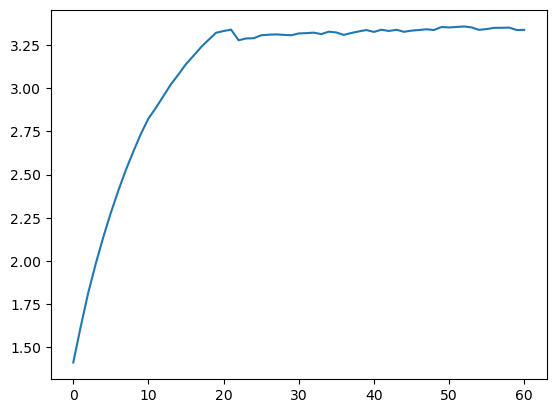

In [5]:
# plot with array of type object
# DataIterObj
# DataIter
plt.plot(np.array(mem_used))

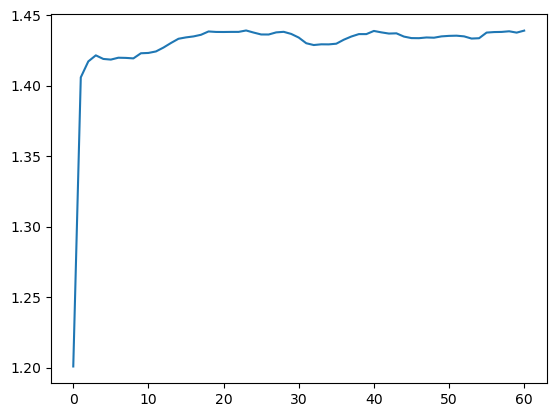

In [5]:
# mem use with fixed length array of type bytes_
# DataIterNp
plt.plot(np.array(mem_used))

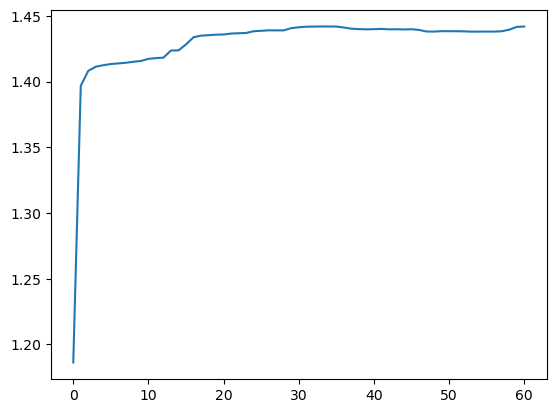

In [4]:
# mem use with fixed length array of type bytes_ + tensor output
# DataIterNpTensor
plt.plot(np.array(mem_used))

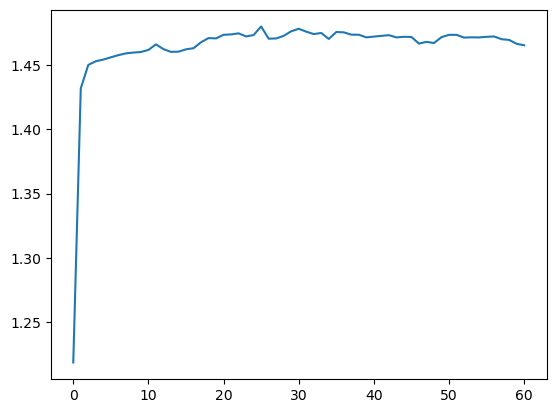

In [6]:
# mem use with fixed length array of type bytes_ + tensor output + dictiionary
# DataIterNpTensorDict
plt.plot(np.array(mem_used))

# HAMData example



In [2]:
#remove_cell
import sys

#datapath = '/Users/Pavel/Documents/'
sourcepath = '/workplace/SkiNet/'

sys.path.insert(0,sourcepath)
#sys.path.insert(0,datapath)

#automatically track changes in the source code
%load_ext autoreload
%autoreload 2


%matplotlib inline


In [ ]:
from SkiNet.ML.datasets.experiments.ham_dataset import HAMDataset, HAMDatasetNpTensorDict
from SkiNet.ML.datasets.ph2dataset import PH2Dataset
from torch.utils.data import DataLoader
from SkiNet.ML.dataloaders.dataloaders import RepeatDataLoader
from SkiNet.ML.datasets.experiments.memory_usage import display_memory_consumption
import matplotlib.pyplot as plt
import numpy as np


# regular dataset
ham_dataset = HAMDataset(data_root="/workplace/SkiNet/HAM60000_resized_2x2")

# dataset where lists of paths to images and masks are wrapped into np.array (dtype bytes)
ham_dataset_nptensor = HAMDatasetNpTensorDict(data_root="/workplace/SkiNet/HAM60000_resized_2x2")


/opt/conda/envs/skinet/lib/python3.11/site-packages/azureml/dataprep/api/_loggerfactory.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


57498


## Data are loaded from a list of paths
## Regular Dataloader  = increased memory consumption

       0 -  43.0 -       1.63 -       2.19 -       1.32
      10 -  44.7 -       1.55 -       2.13 -       1.39
      20 -  45.3 -       1.49 -       2.10 -       1.41
      30 -  45.9 -       1.45 -       2.08 -       1.43
      40 -  46.0 -       1.41 -       2.07 -       1.43
      50 -  46.8 -       1.36 -       2.04 -       1.45
      60 -  47.2 -       1.31 -       2.03 -       1.46
      70 -  47.6 -       1.28 -       2.01 -       1.48
      80 -  48.1 -       1.23 -       1.99 -       1.49
      90 -  48.6 -       1.18 -       1.97 -       1.51


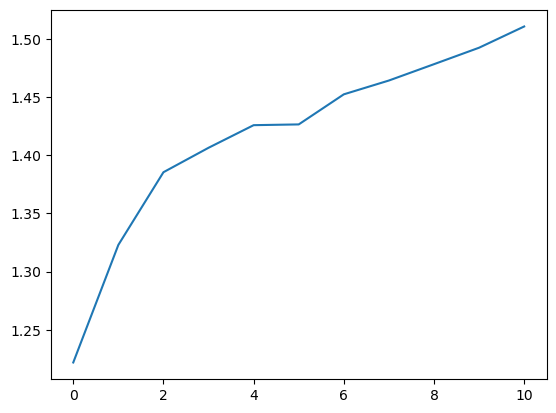

In [3]:
BATCH_SIZE = 600
BATCH_SAMPLING_NUM = 10

train_loader = DataLoader(ham_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,
                          drop_last=True,
                          pin_memory=False,
                          num_workers=4)

mem_used = display_memory_consumption(train_loader, BATCH_SAMPLING_NUM)

plt.plot(np.array(mem_used))
plt.show()


## Data are loaded from a list of paths
## Regular Dataloader w/ persistent workers    =  still increased mem cons

       0 -  46.7 -       1.25 -       2.05 -       1.44
      10 -  48.1 -       1.20 -       1.99 -       1.49
      20 -  49.0 -       1.16 -       1.96 -       1.52
      30 -  49.0 -       1.16 -       1.96 -       1.52
      40 -  49.0 -       1.16 -       1.96 -       1.52
      50 -  49.1 -       1.16 -       1.95 -       1.53
      60 -  49.4 -       1.14 -       1.94 -       1.54
      70 -  49.5 -       1.14 -       1.94 -       1.54
      80 -  49.6 -       1.14 -       1.94 -       1.54
      90 -  49.6 -       1.14 -       1.94 -       1.54


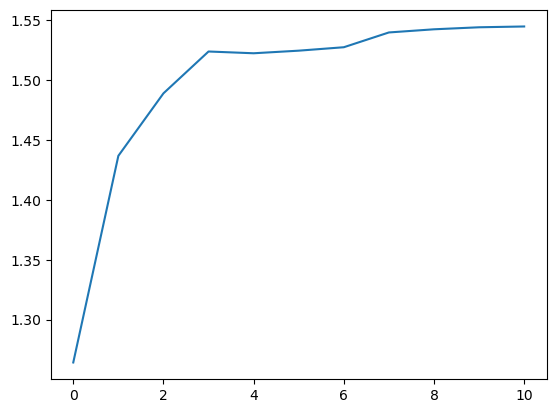

In [4]:
BATCH_SIZE = 600
BATCH_SAMPLING_NUM = 10

train_loader = DataLoader(ham_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,
                          drop_last=True,
                          pin_memory=False,
                           persistent_workers=True,
                          num_workers=4)

mem_used = display_memory_consumption(train_loader, BATCH_SAMPLING_NUM)

plt.plot(np.array(mem_used))
plt.show()


## Data are loaded from a list of paths
## Repeat  Dataloader   - still increased memory consumption

       0 -  46.4 -       1.26 -       2.06 -       1.42
      10 -  48.4 -       1.18 -       1.98 -       1.50
      20 -  49.0 -       1.16 -       1.96 -       1.52
      30 -  49.0 -       1.16 -       1.96 -       1.52
      40 -  49.4 -       1.14 -       1.94 -       1.54
      50 -  49.4 -       1.14 -       1.95 -       1.54
      60 -  49.6 -       1.12 -       1.94 -       1.55
      70 -  49.5 -       1.13 -       1.94 -       1.54
      80 -  49.8 -       1.12 -       1.93 -       1.55
      90 -  49.6 -       1.12 -       1.94 -       1.55


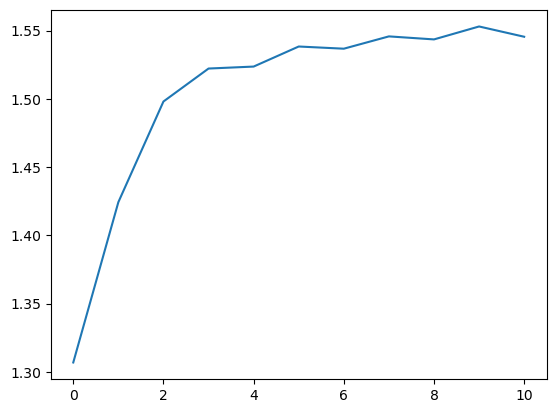

In [4]:
from SkiNet.ML.dataloaders.dataloaders import RepeatDataLoader


BATCH_SIZE = 600
BATCH_SAMPLING_NUM = 10

loader = RepeatDataLoader(
    ham_dataset,
    batch_size=BATCH_SIZE,
    num_workers=4,
    persistent_workers=False,
    max_num_to_repeat=10,
    shuffle=True,
    drop_last=False
)


mem_used = display_memory_consumption(loader, BATCH_SAMPLING_NUM)

plt.plot(np.array(mem_used))
plt.show()




## Data are loaded from a numpy array (type np.bytes_) + dict of tensors output
## Repeat Dataloader

       0 -  46.5 -       1.24 -       2.06 -       1.43
      10 -  46.4 -       1.24 -       2.06 -       1.42
      20 -  46.8 -       1.23 -       2.04 -       1.44
      30 -  46.4 -       1.24 -       2.06 -       1.42
      40 -  46.8 -       1.23 -       2.04 -       1.44
      50 -  46.5 -       1.24 -       2.06 -       1.43
      60 -  46.4 -       1.24 -       2.06 -       1.42
      70 -  46.4 -       1.24 -       2.06 -       1.42
      80 -  46.1 -       1.26 -       2.07 -       1.41
      90 -  46.4 -       1.24 -       2.06 -       1.42


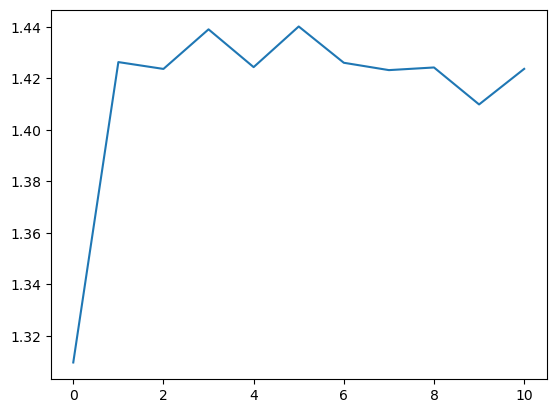

In [3]:
from SkiNet.ML.dataloaders.dataloaders import RepeatDataLoader


BATCH_SIZE = 600
BATCH_SAMPLING_NUM = 10

loader = RepeatDataLoader(
    ham_dataset_nptensor,
    batch_size=BATCH_SIZE,
    num_workers=4,
    persistent_workers=False,
    max_num_to_repeat=10,
    shuffle=True,
    drop_last=False
)


mem_used = display_memory_consumption(loader, BATCH_SAMPLING_NUM)

plt.plot(np.array(mem_used))
plt.show()



## 